Dataset loaded successfully.
Shape of dataset: (569, 31)

FIRST 5 ROWS
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness  mean concavity  \
0        17.99         10.38          122.80     1001.0          0.11840           0.27760          0.3001   
1        20.57         17.77          132.90     1326.0          0.08474           0.07864          0.0869   
2        19.69         21.25          130.00     1203.0          0.10960           0.15990          0.1974   
3        11.42         20.38           77.58      386.1          0.14250           0.28390          0.2414   
4        20.29         14.34          135.10     1297.0          0.10030           0.13280          0.1980   

   mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  \
0              0.14710         0.2419                 0.07871        1.0950         0.9053            8.589   
1              0.07017         0.1812         

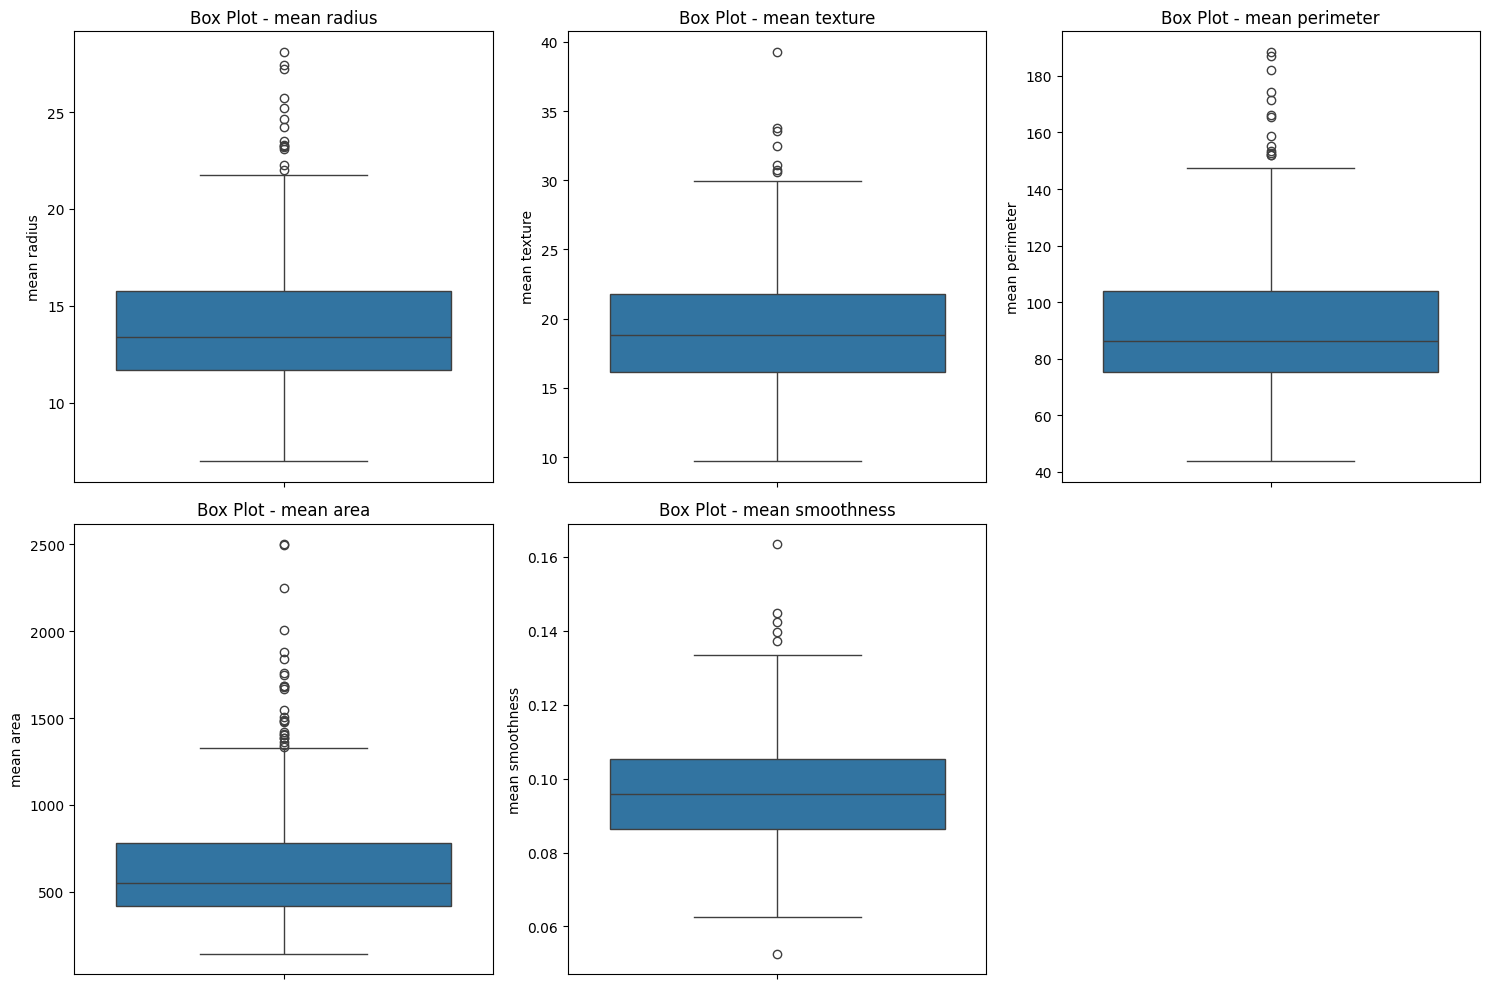


CLASS DISTRIBUTION
Outcome
0    212
1    357
Name: count, dtype: int64

Class labels:
0 = Malignant
1 = Benign

Class percentages:
Outcome
0    37.258348
1    62.741652
Name: proportion, dtype: float64


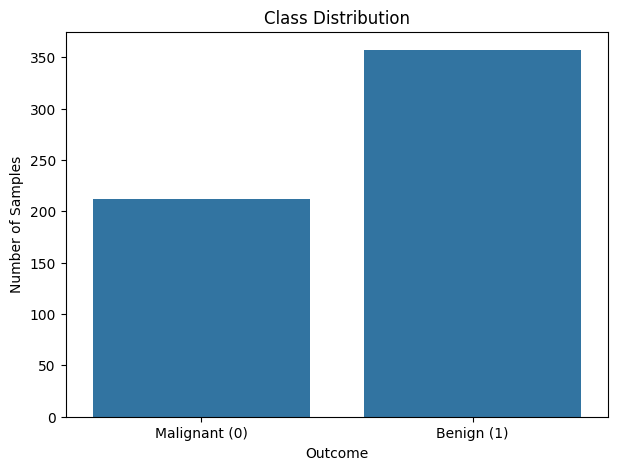

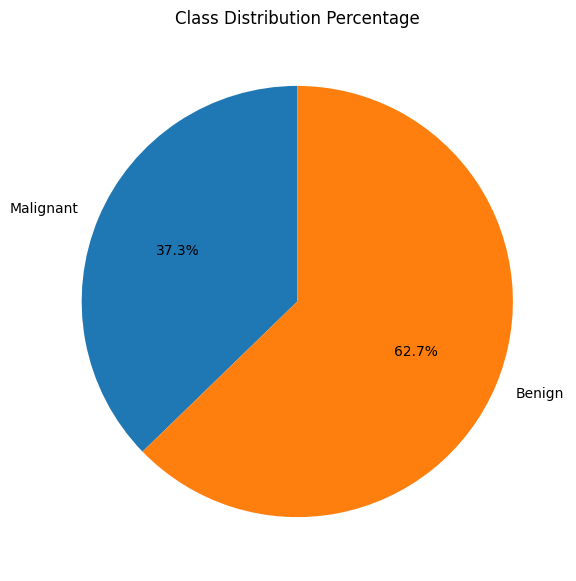

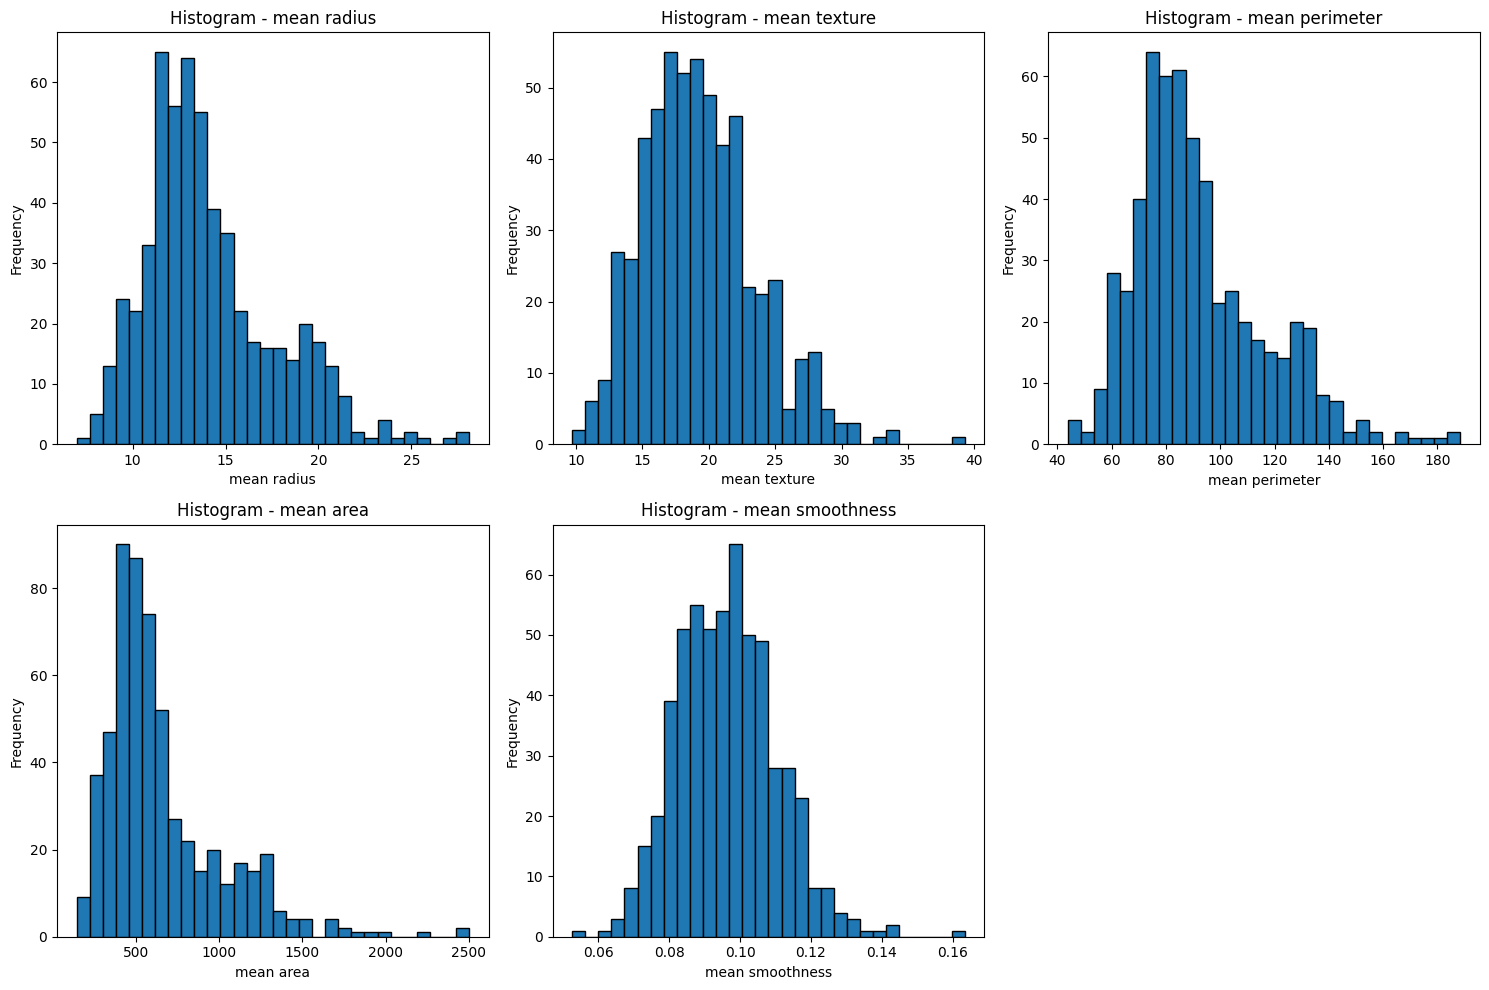

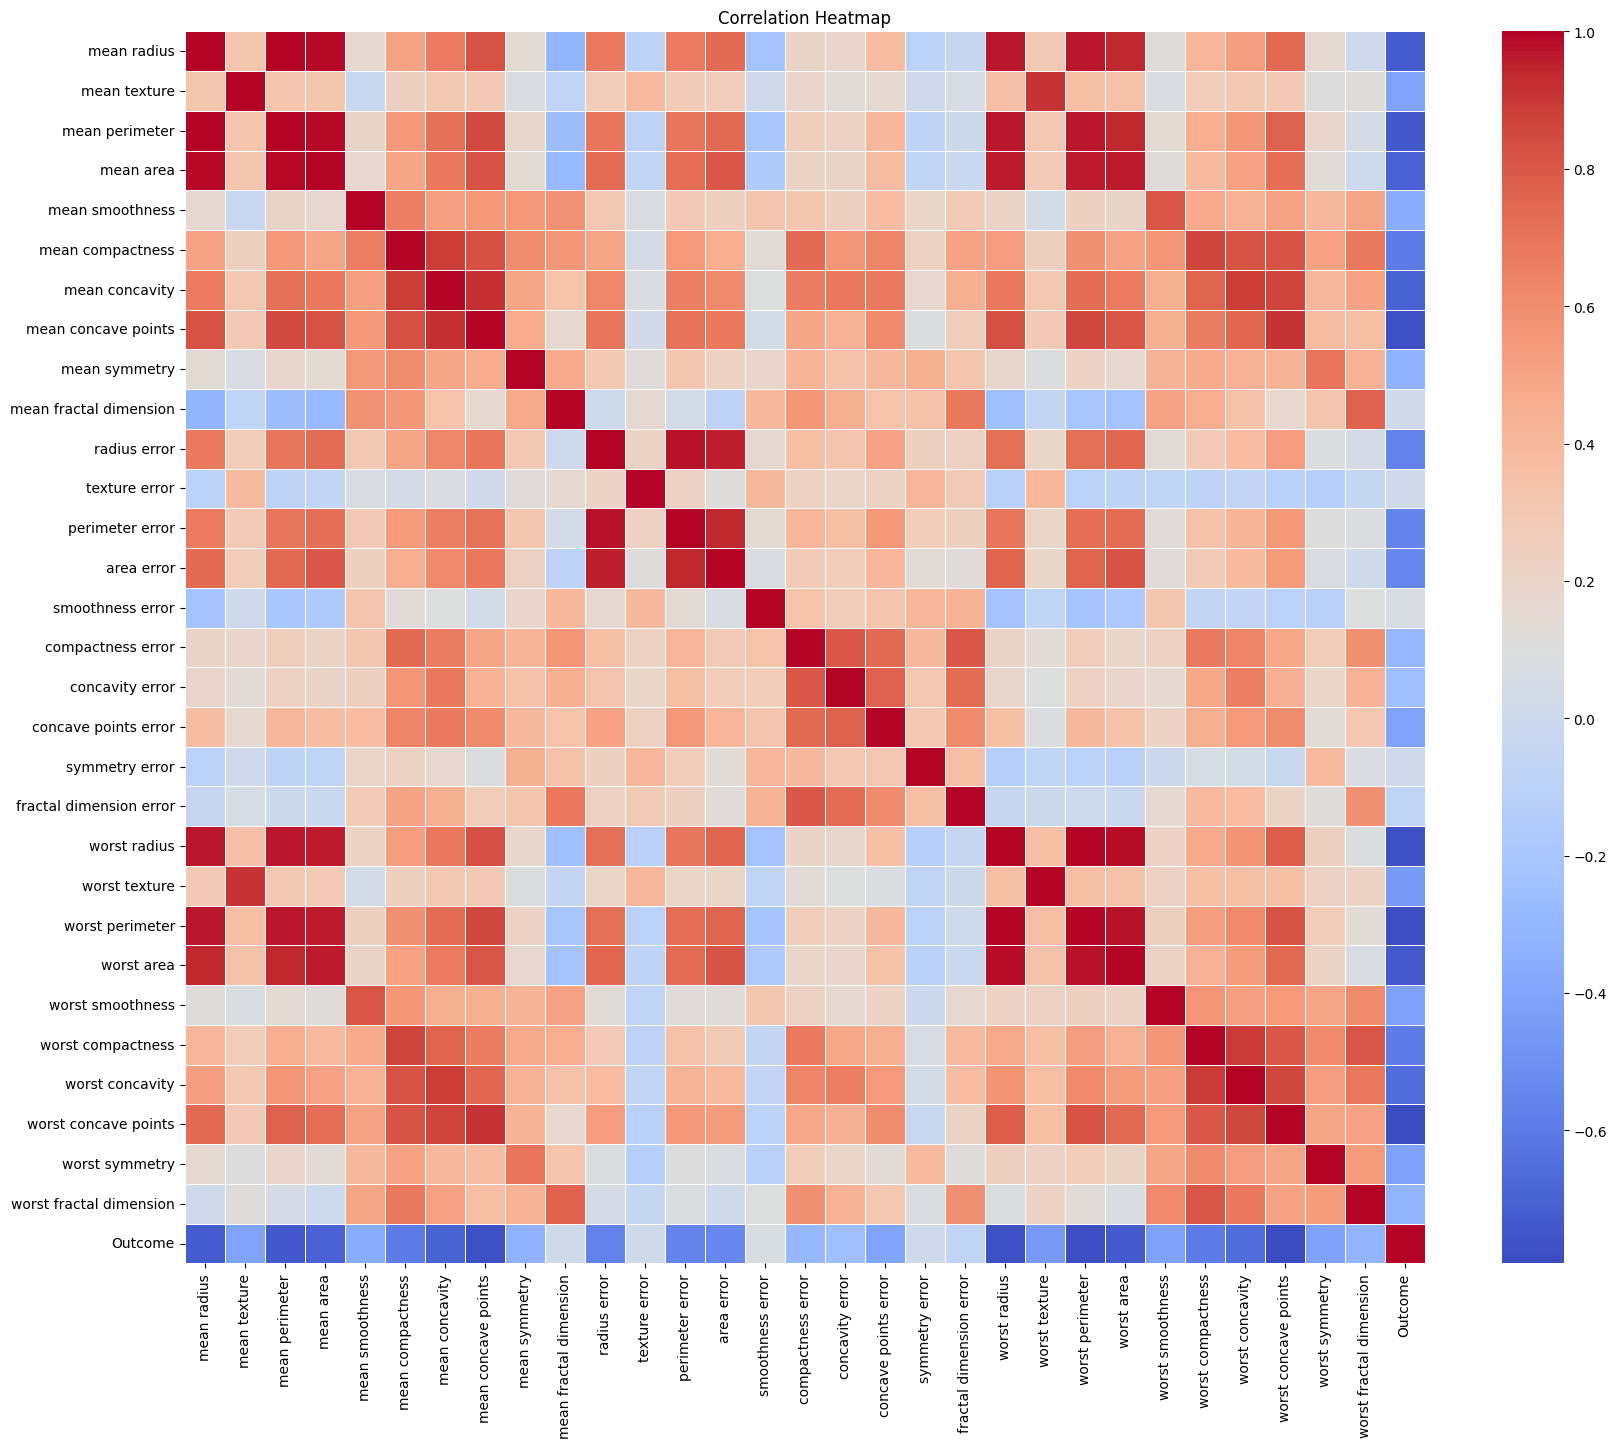


HIGHLY CORRELATED FEATURE PAIRS
          Feature 1               Feature 2  Correlation
        mean radius          mean perimeter     0.997855
        mean radius               mean area     0.987357
        mean radius     mean concave points     0.822529
        mean radius            worst radius     0.969539
        mean radius         worst perimeter     0.965137
        mean radius              worst area     0.941082
       mean texture           worst texture     0.912045
     mean perimeter               mean area     0.986507
     mean perimeter     mean concave points     0.850977
     mean perimeter            worst radius     0.969476
     mean perimeter         worst perimeter     0.970387
     mean perimeter              worst area     0.941550
          mean area     mean concave points     0.823269
          mean area              area error     0.800086
          mean area            worst radius     0.962746
          mean area         worst perimeter     0.95912

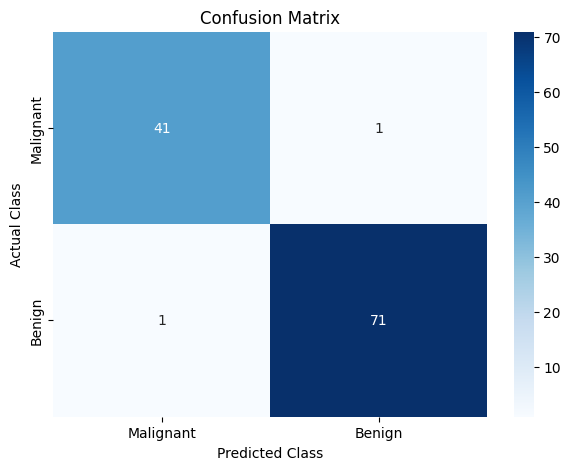


CONFUSION MATRIX COMPONENTS
True Negative  (TN): 41
False Positive (FP): 1
False Negative (FN): 1
True Positive  (TP): 71

ROC-AUC
AUC Score: 0.9953703703703703


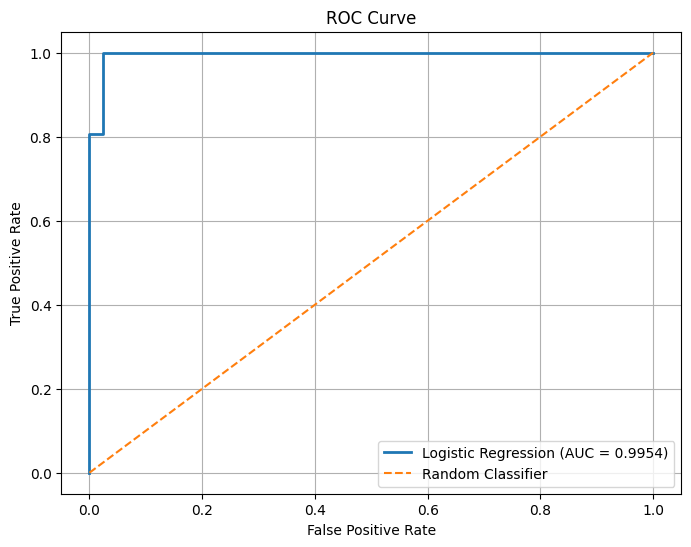


LOGISTIC REGRESSION FEATURE COEFFICIENTS
                Feature  Coefficient  Absolute_Coefficient
          worst texture    -1.255088              1.255088
           radius error    -1.082965              1.082965
   worst concave points    -0.953686              0.953686
             worst area    -0.947756              0.947756
           worst radius    -0.947616              0.947616
         worst symmetry    -0.939181              0.939181
             area error    -0.929104              0.929104
        worst concavity    -0.823151              0.823151
        worst perimeter    -0.763220              0.763220
       worst smoothness    -0.746625              0.746625
    mean concave points    -0.704156              0.704156
       mean compactness     0.648342              0.648342
      compactness error     0.647227              0.647227
         mean concavity    -0.602103              0.602103
           mean texture    -0.552698              0.552698
        perime

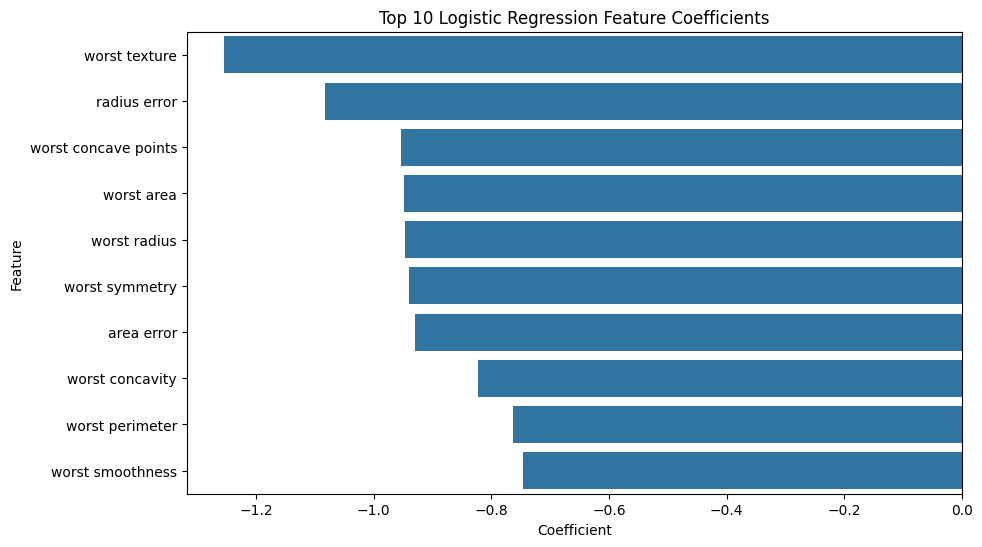

In [1]:
# CSET343 - AI IN HEALTHCARE
# LAB ASSIGNMENT - 4


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)



cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Original sklearn target:
# 0 = Malignant
# 1 = Benign

# Convert target so that:
# 0 = Malignant
# 1 = Benign
df["Outcome"] = cancer.target

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)


print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
print(df.head())

print("\n" + "="*60)
print("LAST 5 ROWS")
print("="*60)
print(df.tail())

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("DATASET SHAPE")
print("="*60)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


print("\n" + "="*60)
print("FEATURE NAMES")
print("="*60)

for i, feature in enumerate(cancer.feature_names, start=1):
    print(i, ":", feature)


print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(df.describe())

# Mean
print("\n" + "="*60)
print("MEAN OF ALL NUMERICAL FEATURES")
print("="*60)

print(df.drop(columns=["Outcome"]).mean())

# Median
print("\n" + "="*60)
print("MEDIAN OF ALL NUMERICAL FEATURES")
print("="*60)

print(df.drop(columns=["Outcome"]).median())

# Standard deviation
print("\n" + "="*60)
print("STANDARD DEVIATION OF ALL NUMERICAL FEATURES")
print("="*60)

print(df.drop(columns=["Outcome"]).std())


print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

missing_values = df.isnull().sum()

print(missing_values)

total_missing = missing_values.sum()

print("\nTotal missing values:", total_missing)

if total_missing == 0:
    print("No missing values found.")
else:
    print("Missing values found. Handling missing values...")
    for column in df.columns:
        if df[column].isnull().sum() > 0:
            if column != "Outcome":
                df[column].fillna(df[column].median(), inplace=True)


print("\n" + "="*60)
print("DUPLICATE RECORDS")
print("="*60)

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")


print("\n" + "="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)


print("\n" + "="*60)
print("OUTLIER DETECTION USING IQR")
print("="*60)

numeric_features = df.drop(columns=["Outcome"])

outlier_summary = {}

for column in numeric_features.columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

outlier_table = pd.DataFrame(
    list(outlier_summary.items()),
    columns=["Feature", "Number_of_Outliers"]
)

print(outlier_table.to_string(index=False))

print("\nTotal detected feature-wise outliers:",
      outlier_table["Number_of_Outliers"].sum())


# Plot selected important features
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(selected_features, 1):

    plt.subplot(2, 3, i)

    sns.boxplot(y=df[feature])

    plt.title("Box Plot - " + feature)

plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)

class_counts = df["Outcome"].value_counts().sort_index()

print(class_counts)

print("\nClass labels:")
print("0 = Malignant")
print("1 = Benign")

# Percentage distribution
class_percentage = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("\nClass percentages:")
print(class_percentage)


plt.figure(figsize=(7, 5))

sns.countplot(
    x="Outcome",
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Samples")

plt.xticks(
    [0, 1],
    ["Malignant (0)", "Benign (1)"]
)

plt.show()

# Pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    class_counts.values,
    labels=["Malignant", "Benign"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution Percentage")

plt.show()


plt.figure(figsize=(15, 10))

for i, feature in enumerate(selected_features, 1):

    plt.subplot(2, 3, i)

    plt.hist(df[feature], bins=30, edgecolor="black")

    plt.title("Histogram - " + feature)
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


plt.figure(figsize=(20, 16))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()


print("\n" + "="*60)
print("HIGHLY CORRELATED FEATURE PAIRS")
print("="*60)

corr = df.drop(columns=["Outcome"]).corr()

high_corr_pairs = []

for i in range(len(corr.columns)):

    for j in range(i + 1, len(corr.columns)):

        correlation_value = corr.iloc[i, j]

        if abs(correlation_value) >= 0.80:

            high_corr_pairs.append(
                (
                    corr.columns[i],
                    corr.columns[j],
                    correlation_value
                )
            )

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

print(high_corr_df.to_string(index=False))


print("\n" + "="*60)
print("TARGET VALUES")
print("="*60)

print(df["Outcome"].unique())


X = df.drop(columns=["Outcome"])
y = df["Outcome"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\n" + "="*60)
print("FEATURE STANDARDIZATION")
print("="*60)

print("Standardization completed successfully.")

# Convert scaled arrays back to DataFrame for viewing
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

print("\nFirst 5 standardized training samples:")
print(X_train_scaled_df.head())


logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("\n" + "="*60)
print("LOGISTIC REGRESSION MODEL")
print("="*60)

print("Model training completed.")

y_pred = logistic_model.predict(X_test_scaled)

# Probability prediction for positive class
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

print("\nFirst 20 Predicted Values:")
print(y_pred[:20])


accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*60)
print("ACCURACY")
print("="*60)

print("Accuracy:", accuracy)


precision = precision_score(
    y_test,
    y_pred,
    average=None
)

print("\n" + "="*60)
print("PRECISION FOR BOTH CLASSES")
print("="*60)

print("Malignant (Class 0):", precision[0])
print("Benign   (Class 1):", precision[1])


recall = recall_score(
    y_test,
    y_pred,
    average=None
)

print("\n" + "="*60)
print("RECALL FOR BOTH CLASSES")
print("="*60)

print("Malignant (Class 0):", recall[0])
print("Benign   (Class 1):", recall[1])


f1 = f1_score(
    y_test,
    y_pred,
    average=None
)

print("\n" + "="*60)
print("F1 SCORE FOR BOTH CLASSES")
print("="*60)

print("Malignant (Class 0):", f1[0])
print("Benign   (Class 1):", f1[1])


print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)


cm = confusion_matrix(y_test, y_pred)

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

print(cm)

# Visualize confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


TN, FP, FN, TP = cm.ravel()

print("\n" + "="*60)
print("CONFUSION MATRIX COMPONENTS")
print("="*60)

print("True Negative  (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive  (TP):", TP)


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("\n" + "="*60)
print("ROC-AUC")
print("="*60)

print("AUC Score:", auc_score)

# Plot ROC curve

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label="Logistic Regression (AUC = {:.4f})".format(auc_score)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()


coefficients = logistic_model.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\n" + "="*60)
print("LOGISTIC REGRESSION FEATURE COEFFICIENTS")
print("="*60)

print(coefficient_df.to_string(index=False))

print("\n" + "="*60)
print("TOP 10 FEATURES BASED ON ABSOLUTE COEFFICIENT")
print("="*60)

print(
    coefficient_df.head(10)[
        ["Feature", "Coefficient"]
    ].to_string(index=False)
)


top_features = coefficient_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Logistic Regression Feature Coefficients")

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()


metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision - Malignant",
        "Precision - Benign",
        "Recall - Malignant",
        "Recall - Benign",
        "F1 Score - Malignant",
        "F1 Score - Benign",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision[0],
        precision[1],
        recall[0],
        recall[1],
        f1[0],
        f1[1],
        auc_score
    ]
})


